# 📚 Goodreads Books Analysis

**Tujuan:** Menganalisis tren dan pola pada dataset buku Goodreads
untuk menemukan insight seputar popularitas buku, penulis, dan rating.

**Dataset:** Goodreads-books by Soumik (Kaggle)

**Tools:** Python, Pandas, Matplotlib, Seaborn

**Framework:** CRISP-DM

**Author:** Nikmatul Khasanah

## Data Understanding

In [1]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/niknycto/dataset/refs/heads/main/books.csv',
                 on_bad_lines='skip')
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


menggunakan on_bad_list='skip' karena ada data (baris) yang tidak konsisten di dataset, yaitu baris ke 3350, punya kolom lebih dari seharusnya

In [2]:
# Menampilkan setiap kolom
for column in df.columns:
    print(column)

bookID
title
authors
average_rating
isbn
isbn13
language_code
  num_pages
ratings_count
text_reviews_count
publication_date
publisher


In [3]:
df.shape

(11123, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  object 
 2   authors             11123 non-null  object 
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  object 
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  object 
 7     num_pages         11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  object 
 11  publisher           11123 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


In [5]:
df.nunique()

,0
bookID,11123
title,10348
authors,6639
average_rating,209
isbn,11123
isbn13,11123
language_code,27
num_pages,997
ratings_count,5294
text_reviews_count,1822


In [6]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Nilai dalam kolom '{column}':\n{unique_values}")

Nilai dalam kolom 'bookID':
[    1     2     4 ... 45634 45639 45641]
Nilai dalam kolom 'title':
['Harry Potter and the Half-Blood Prince (Harry Potter  #6)'
 'Harry Potter and the Order of the Phoenix (Harry Potter  #5)'
 'Harry Potter and the Chamber of Secrets (Harry Potter  #2)' ...
 'The Ice-Shirt (Seven Dreams #1)' 'Poor People'
 'Las aventuras de Tom Sawyer']
Nilai dalam kolom 'authors':
['J.K. Rowling/Mary GrandPré' 'J.K. Rowling' 'W. Frederick Zimmerman' ...
 'C.S. Lewis/Ana Falcão Bastos'
 'C.S. Lewis/Pauline Baynes/Ana Falcão Bastos'
 'William T. Vollmann/Larry McCaffery/Michael Hemmingson']
Nilai dalam kolom 'average_rating':
[4.57 4.49 4.42 4.56 4.78 3.74 4.73 4.38 4.22 4.21 3.44 3.87 4.07 3.9
 3.83 3.86 3.91 3.93 4.59 4.5  4.36 4.53 3.84 3.72 4.   3.88 4.33 3.45
 3.76 3.6  4.06 4.17 3.55 3.98 4.13 3.95 4.24 4.34 3.92 4.23 3.75 3.94
 3.77 4.46 3.68 3.99 3.25 3.89 3.82 3.78 4.01 4.35 4.28 3.34 3.67 3.48
 3.5  3.62 4.27 3.39 4.12 4.08 4.05 3.85 2.99 4.19 3.71 4.2  3.65 3.4
 

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bookID,11123.0,2.131086e+04,1.309473e+04,1.000000e+00,1.027750e+04,2.028700e+04,3.210450e+04,4.564100e+04
average_rating,11123.0,3.934075e+00,3.504853e-01,0.000000e+00,3.770000e+00,3.960000e+00,4.140000e+00,5.000000e+00
isbn13,11123.0,9.759880e+12,4.429758e+11,8.987060e+09,9.780345e+12,9.780582e+12,9.780872e+12,9.790008e+12
num_pages,11123.0,3.364056e+02,2.411526e+02,0.000000e+00,1.920000e+02,2.990000e+02,4.160000e+02,6.576000e+03
ratings_count,11123.0,1.794285e+04,1.124992e+05,0.000000e+00,1.040000e+02,7.450000e+02,5.000500e+03,4.597666e+06
text_reviews_count,11123.0,5.420481e+02,2.576620e+03,0.000000e+00,9.000000e+00,4.700000e+01,2.380000e+02,9.426500e+04


In [8]:
df.duplicated().sum()

np.int64(0)

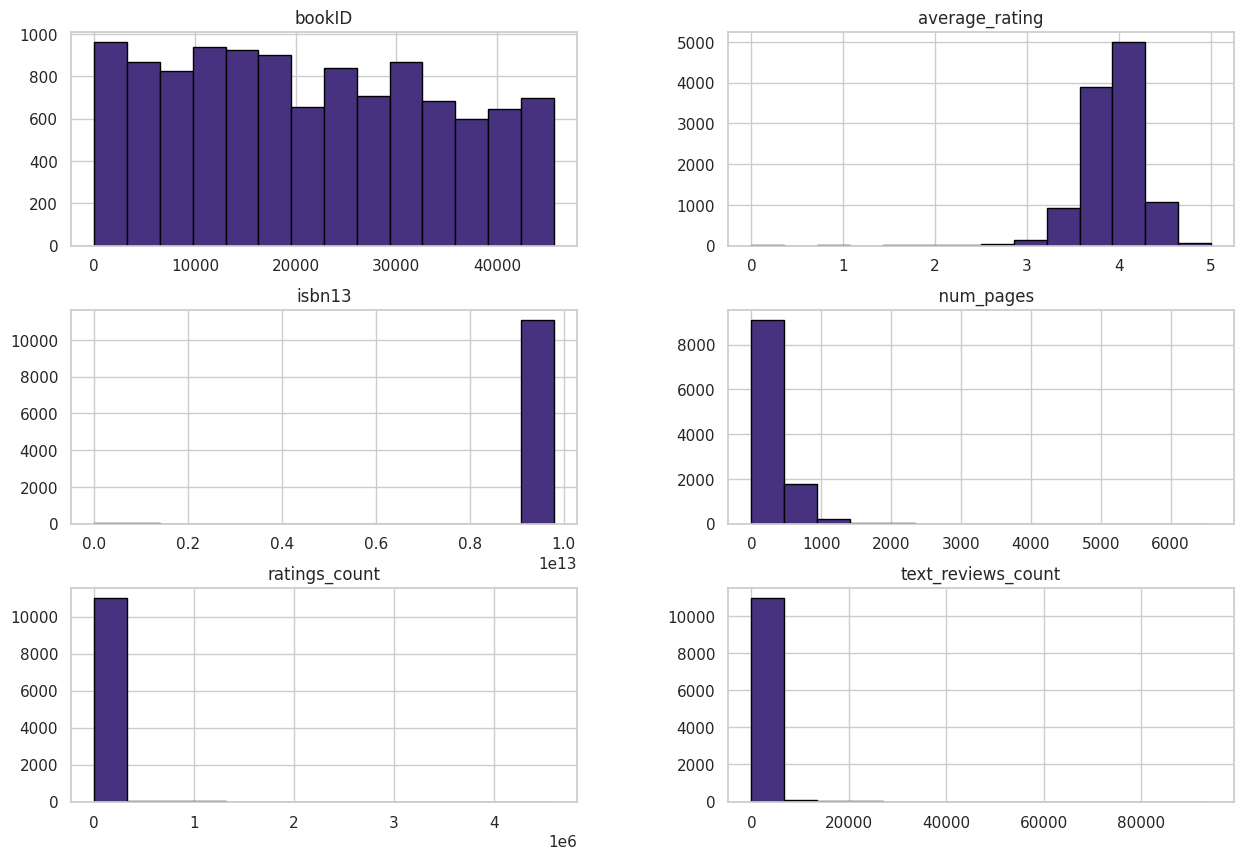

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

num_bins = int(np.log2(len(df))+1)
sns.set(style='whitegrid', palette='viridis')
df.hist(bins=num_bins, figsize=(15,10), edgecolor='black')
plt.show()

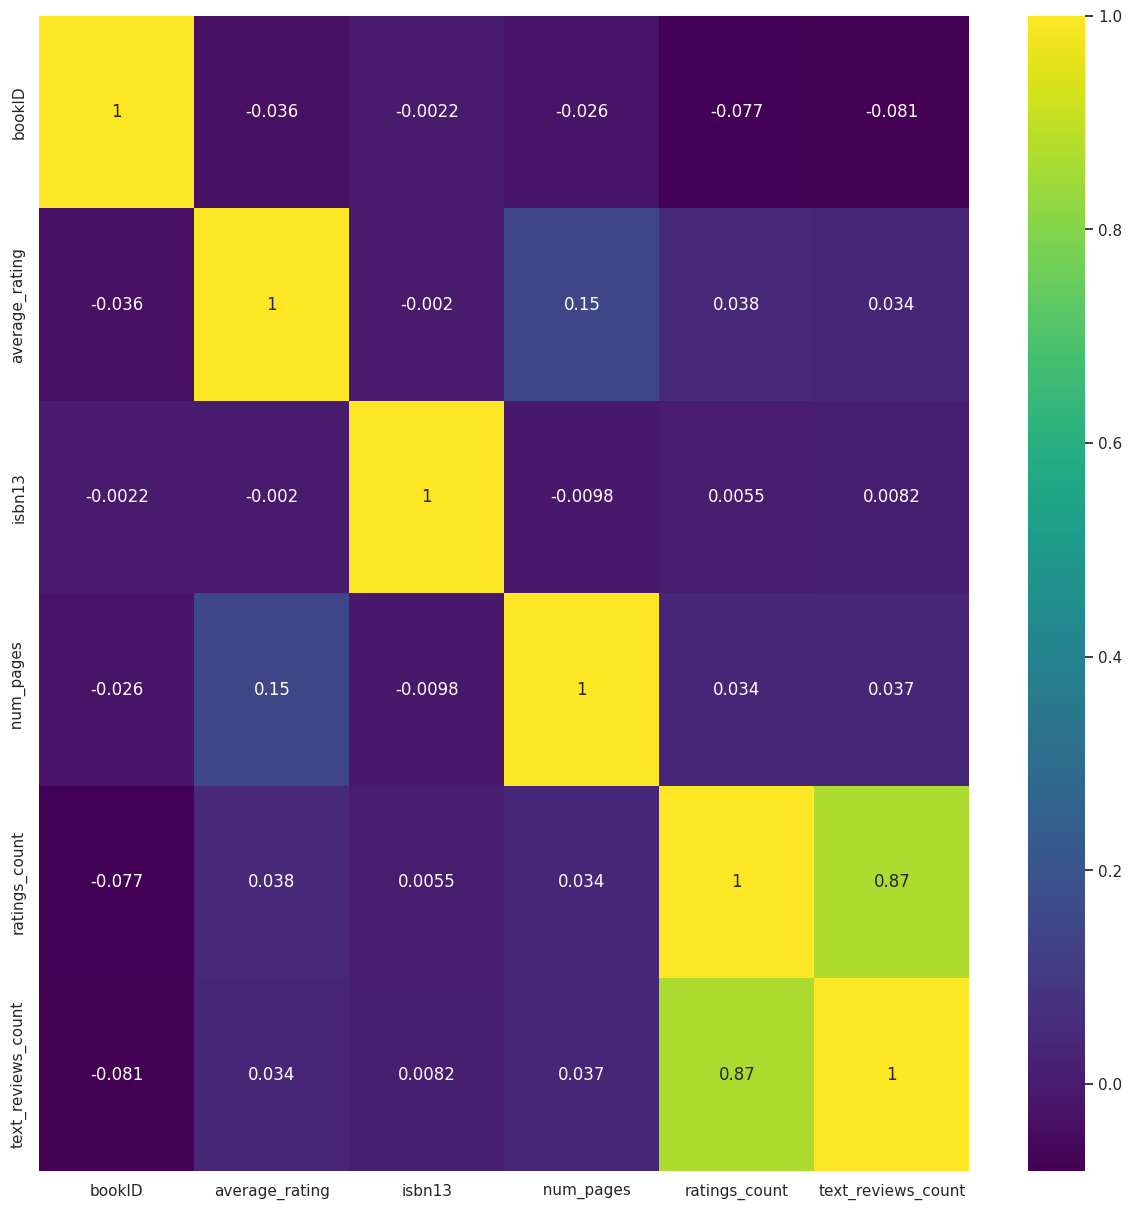

In [10]:
df_numerik = df.select_dtypes(include='number')
correlation = df_numerik.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(correlation, annot=True, cmap='viridis')
plt.show()

In [11]:
df_numerik.corr()

,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
bookID,1.000000,-0.036207,-0.002185,-0.026134,-0.076820,-0.081289
average_rating,-0.036207,1.000000,-0.001965,0.150477,0.038224,0.033663
isbn13,-0.002185,-0.001965,1.000000,-0.009818,0.005494,0.008152
num_pages,-0.026134,0.150477,-0.009818,1.000000,0.034337,0.036977
ratings_count,-0.076820,0.038224,0.005494,0.034337,1.000000,0.865977
text_reviews_count,-0.081289,0.033663,0.008152,0.036977,0.865977,1.000000


In [12]:
df.isnull().sum()

,0
bookID,0
title,0
authors,0
average_rating,0
isbn,0
isbn13,0
language_code,0
num_pages,0
ratings_count,0
text_reviews_count,0


## Data Cleaning

In [13]:
import scipy.stats as stats

z_score_threshold = 3
z_scores = stats.zscore(df.select_dtypes(include='number'))
outliers = (abs(z_scores) > z_score_threshold).any(axis=1)

print("Baris yang berisi outlier:")
df[outliers]

Baris yang berisi outlier:


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic
6,10,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,4.73,0439827604,9780439827607,eng,3342,28242,808,9/12/2005,Scholastic
...,...,...,...,...,...,...,...,...,...,...,...,...
10914,44652,Fablehaven (Fablehaven #1),Brandon Mull,4.10,1590385810,9781590385814,eng,351,117341,8718,6/7/2006,Shadow Mountain
10917,44705,The Leadership Challenge: Skills for Taking Ch...,Warren G. Bennis,0.00,088684049X,9780886840495,eng,60,0,0,12/1/1985,AMR/Advanced Management Reports
10956,44919,Working Effectively with Legacy Code,Michael C. Feathers,4.14,0131177052,76092025986,eng,464,3450,195,9/1/2004,Prentice Hall
11027,45259,Anthony Thwaite: In Conversation With Peter Da...,Peter Dale/Ian Hamilton/Anthony Thwaite,0.00,0953284123,9780953284122,eng,96,0,0,12/9/1999,Between the Lines Productions


In [14]:
outliers_row = 428
percentage_outliers = outliers_row / len(df) *100
print("Persentase Outliers:", percentage_outliers)

Persentase Outliers: 3.8478827654409784


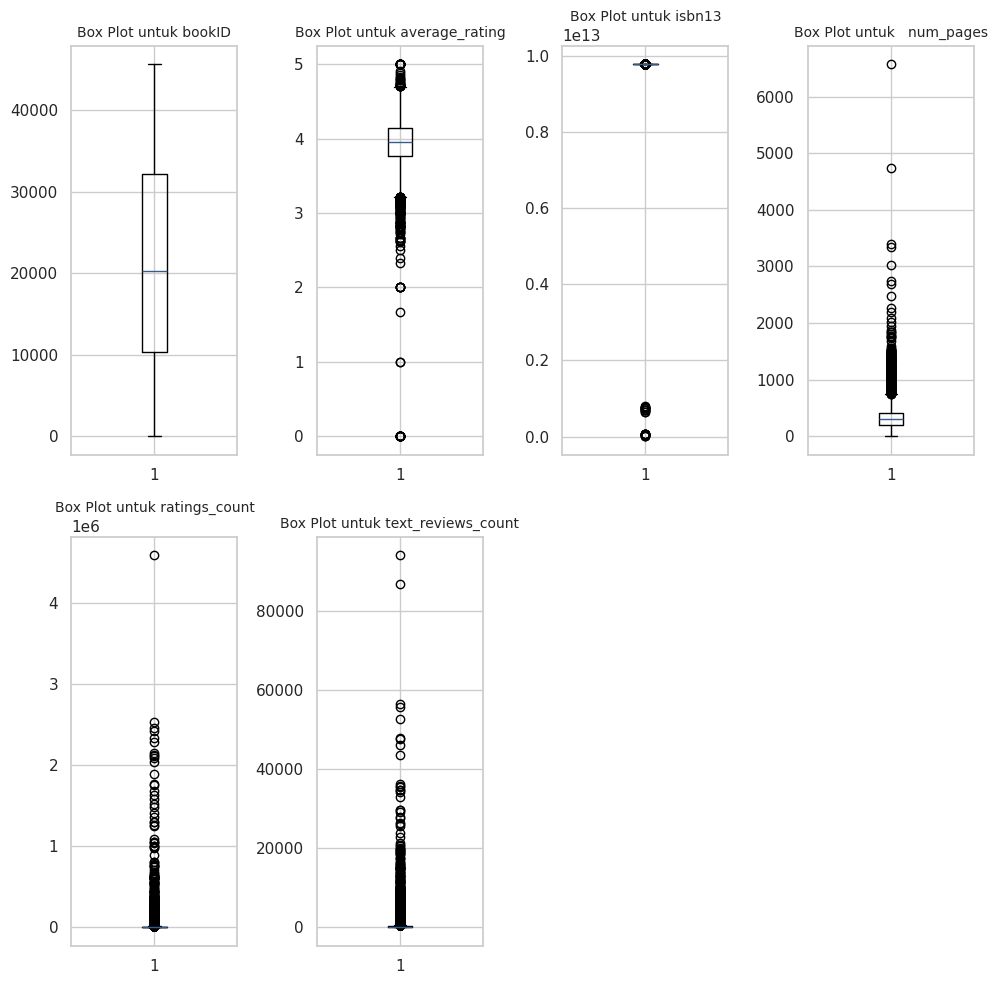

In [15]:
num_df = df.select_dtypes(include='number')

num_cols = len(num_df.columns)
num_rows = (num_cols // 4) + 1 if num_cols % 4 != 0 else num_cols // 4

plt.figure(figsize=(10, 5 * num_rows))

for i, column in enumerate(num_df.columns, 1):
    plt.subplot(num_rows, 4, i)
    plt.boxplot(num_df[column].dropna())
    plt.title('Box Plot untuk {}'.format(column), fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
# Cek buku dengan rating 0
df[df['average_rating'] == 0][['title', 'authors', 'average_rating', 'ratings_count']]

,title,authors,average_rating,ratings_count
265,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0.0,0
375,Juiced Official Strategy Guide,Doug Walsh,0.0,0
987,Open City 6: The Only Woman He Ever Left,Open City Magazine/James Purdy/Daniel Pinchbec...,0.0,0
2532,How To Meditate: An Anthology Of Talks On Medi...,Frederick P. Lenz,0.0,0
2533,Insights: Talks On The Nature Of Existence,Frederick P. Lenz,0.0,0
2758,Venac sonetnih venaca; Puževa srma,Dobrica Erić,0.0,0
3492,Brodie's notes on Aldous Huxley's brave new world,Graham Handley,0.0,0
4241,American Film Guide,Frank N. Magill,0.0,0
4677,The Man and the Author: John Milton: Twentieth...,J. Martin Evans,0.0,0
5323,Canopy: A Work for Voice and Light in Harvard ...,David Ward/Parveen Adams/Seamus Heaney/Ivan ...,0.0,0


In [17]:
df1 = df[df['average_rating'] > 0]

hapus baris yang memiliki rating 0, karena elum diulas atau belum dibaca

In [18]:
print(df1.columns.tolist())

['bookID', 'title', 'authors', 'average_rating', 'isbn', 'isbn13', 'language_code', '  num_pages', 'ratings_count', 'text_reviews_count', 'publication_date', 'publisher']


In [19]:
df1.columns = df1.columns.str.strip()

In [20]:
Q1 = df1['num_pages'].quantile(0.25)
Q3 = df1['num_pages'].quantile(0.75)
IQR = Q3 - Q1
df1 = df1[(df1['num_pages'] >= Q1 - 1.5*IQR) &
        (df1['num_pages'] <= Q3 + 1.5*IQR)]

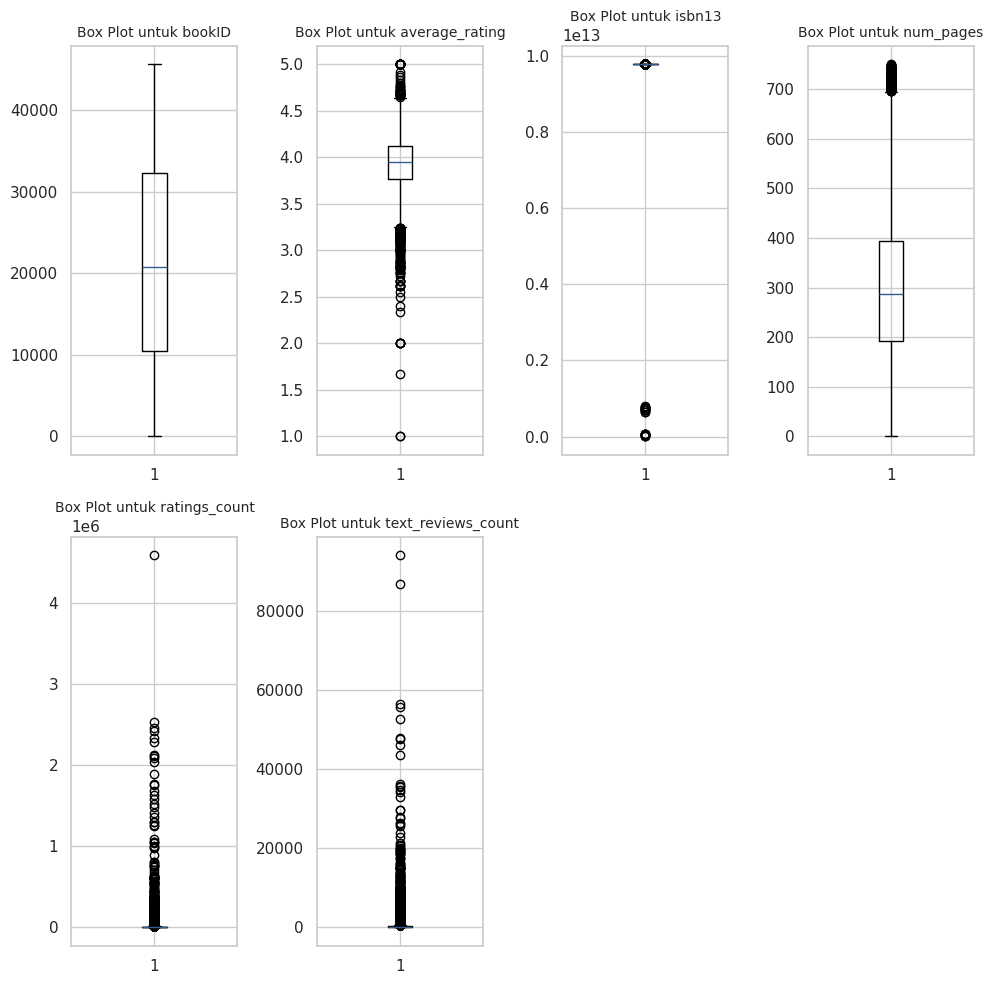

In [21]:
num_df1 = df1.select_dtypes(include='number')

num_cols = len(num_df1.columns)
num_rows = (num_cols // 4) + 1 if num_cols % 4 != 0 else num_cols // 4

plt.figure(figsize=(10, 5 * num_rows))

for i, column in enumerate(num_df1.columns, 1):
    plt.subplot(num_rows, 4, i)
    plt.boxplot(num_df1[column].dropna())
    plt.title('Box Plot untuk {}'.format(column), fontsize=10)

plt.tight_layout()
plt.show()

## Exploratory Data Analyst

### Distribusi Rating Buku

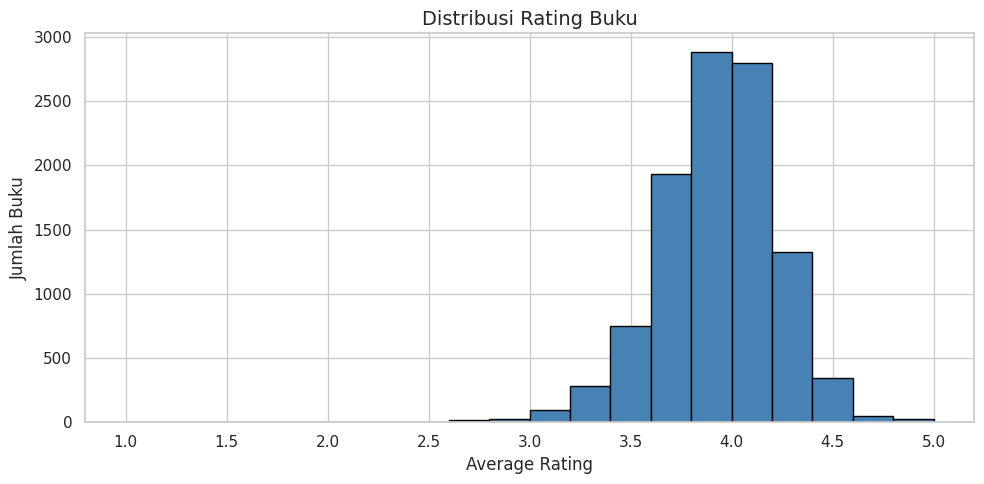

Statistik Distribusi Rating:
Rata-rata rating : 3.93
Rating tertinggi : 5.00
Rating terendah  : 1.00
Rating terbanyak : 4.00
Total buku       : 10,541


In [23]:
import matplotlib.pyplot as plt

df2 = df1

plt.figure(figsize=(10, 5))
plt.hist(df2['average_rating'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribusi Rating Buku', fontsize=14)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Jumlah Buku', fontsize=12)
plt.tight_layout()
plt.show()

# Statistik deskriptif rating
print("Statistik Distribusi Rating:")
print(f"Rata-rata rating : {df2['average_rating'].mean():.2f}")
print(f"Rating tertinggi : {df2['average_rating'].max():.2f}")
print(f"Rating terendah  : {df2['average_rating'].min():.2f}")
print(f"Rating terbanyak : {df2['average_rating'].mode()[0]:.2f}")
print(f"Total buku       : {len(df2):,}")

**Insight Distribusi Rating:**

Distribusi rating miring ke kiri (left-skewed) — mayoritas buku mendapat rating tinggi
Sebagian besar buku berada di rentang rating 3.75 - 4.25
Rata-rata rating 3.93 — menunjukkan pembaca Goodreads cenderung memberi rating positif
Hanya sedikit buku yang mendapat rating di bawah 3.0

### Top 10 buku paling banyak dibaca

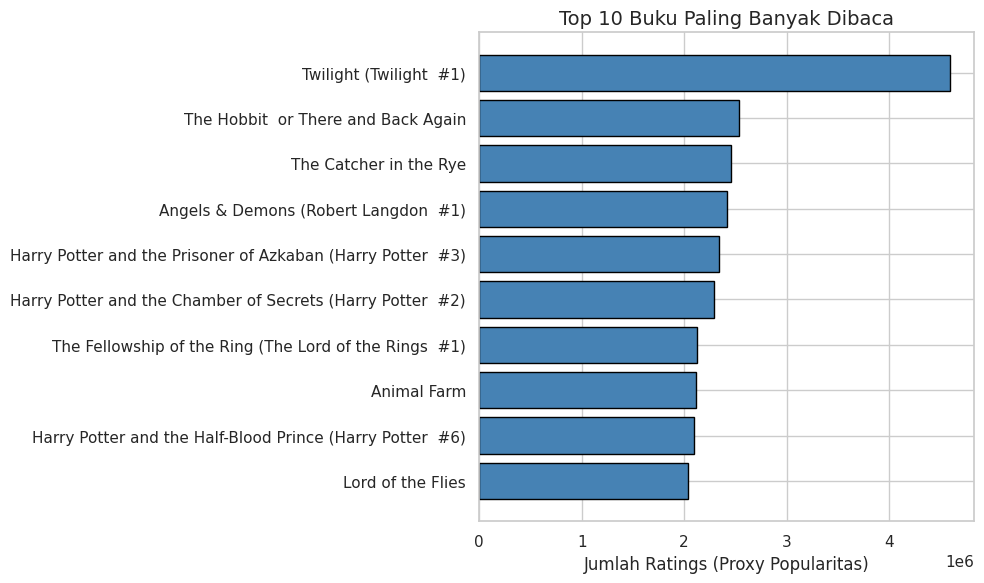

                                                      title                                 authors  ratings_count
                                    Twilight (Twilight  #1)                         Stephenie Meyer        4597666
                        The Hobbit  or There and Back Again                          J.R.R. Tolkien        2530894
                                     The Catcher in the Rye                           J.D. Salinger        2457092
                       Angels & Demons (Robert Langdon  #1)                               Dan Brown        2418736
Harry Potter and the Prisoner of Azkaban (Harry Potter  #3)              J.K. Rowling/Mary GrandPré        2339585
 Harry Potter and the Chamber of Secrets (Harry Potter  #2)              J.K. Rowling/Mary GrandPré        2293963
     The Fellowship of the Ring (The Lord of the Rings  #1)                          J.R.R. Tolkien        2128944
                                                Animal Farm George Orwell/Boris 

In [24]:
top_books = df2.nlargest(10, 'ratings_count')[['title', 'authors', 'ratings_count']]

plt.figure(figsize=(10, 6))
plt.barh(top_books['title'], top_books['ratings_count'], color='steelblue', edgecolor='black')
plt.xlabel('Jumlah Ratings (Proxy Popularitas)', fontsize=12)
plt.title('Top 10 Buku Paling Banyak Dibaca', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_books.to_string(index=False))

*   Twilight jauh mengungguli buku lain dengan hampir 4.6 juta ratings
*   Harry Potter series mendominasi daftar (3 dari 10 buku) — menunjukkan loyalitas pembaca terhadap satu franchise
*   Mayoritas top 10 adalah buku fiksi klasik/fantasi yang populer di kalangan luas







### Top 10 Bahasa Buku Paling Populer

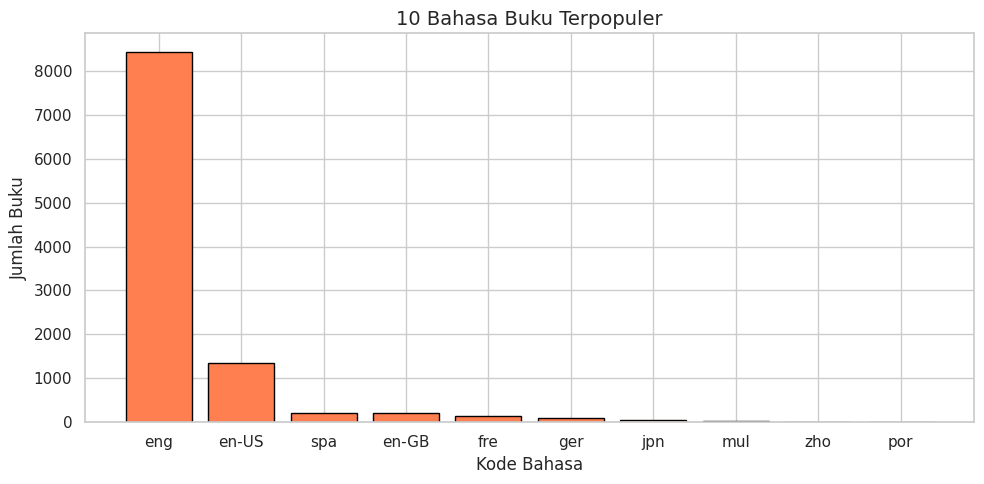

language_code
eng      8431
en-US    1340
spa       209
en-GB     208
fre       135
ger        92
jpn        46
mul        19
zho        13
por        10
Name: count, dtype: int64


In [25]:
lang_counts = df2['language_code'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(lang_counts.index, lang_counts.values, color='coral', edgecolor='black')
plt.xlabel('Kode Bahasa', fontsize=12)
plt.ylabel('Jumlah Buku', fontsize=12)
plt.title('10 Bahasa Buku Terpopuler', fontsize=14)
plt.tight_layout()
plt.show()

print(lang_counts)

*  Bahasa Inggris (eng + en-US + en-GB) mendominasi total dengan hampir 9.979 buku atau sekitar 94% dari keseluruhan dataset
*  Bahasa lain seperti Spanyol, Prancis, Jerman, Jepang jumlahnya sangat kecil dibanding Inggris
*  Ini menunjukkan bias dataset — kemungkinan Goodreads API lebih banyak mengindeks buku berbahasa Inggris

**Catatan:**
Dataset ini didominasi buku berbahasa Inggris, sehingga hasil analisis lebih merepresentasikan tren pembaca berbahasa Inggris, bukan tren membaca global secara keseluruhan.

### Top 10 Penulis Paling Produktif

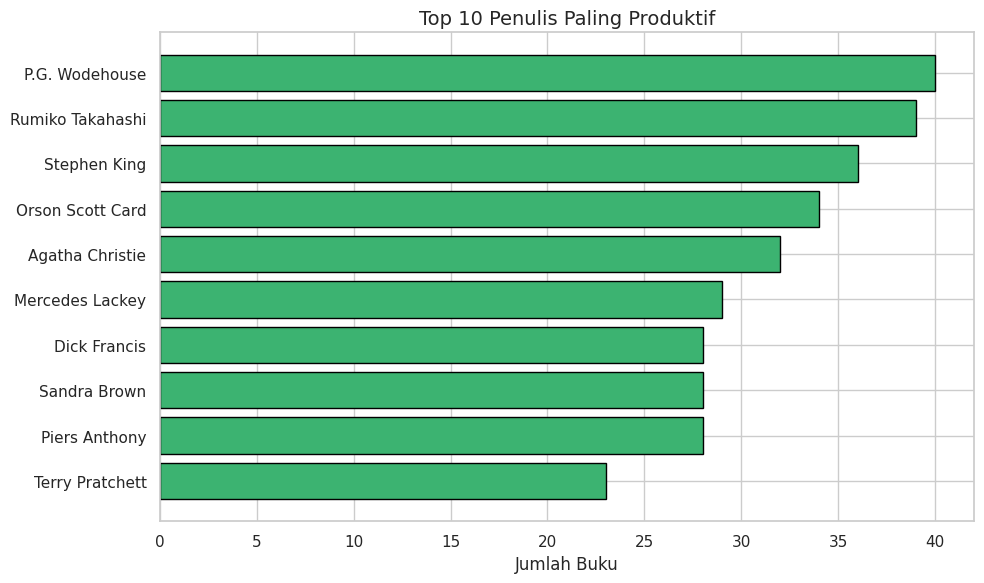

authors
P.G. Wodehouse      40
Rumiko Takahashi    39
Stephen King        36
Orson Scott Card    34
Agatha Christie     32
Mercedes Lackey     29
Dick Francis        28
Sandra Brown        28
Piers Anthony       28
Terry Pratchett     23
Name: count, dtype: int64


In [26]:
top_authors = df2['authors'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_authors.index, top_authors.values, color='mediumseagreen', edgecolor='black')
plt.xlabel('Jumlah Buku', fontsize=12)
plt.title('Top 10 Penulis Paling Produktif', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_authors)

*  P.G. Wodehouse menjadi penulis paling produktif dengan 40 buku di dataset
*  Diikuti Rumiko Takahashi (mangaka Jepang) dengan 39 buku — menarik karena bahasa Jepang sendiri minoritas di dataset
*  Stephen King dan Agatha Christie masuk daftar — sesuai ekspektasi karena mereka memang dikenal sangat prolifik
*  Daftar ini didominasi penulis genre fiksi, misteri, dan fantasi

### Hubungan Rating dengan Jumlah Halaman

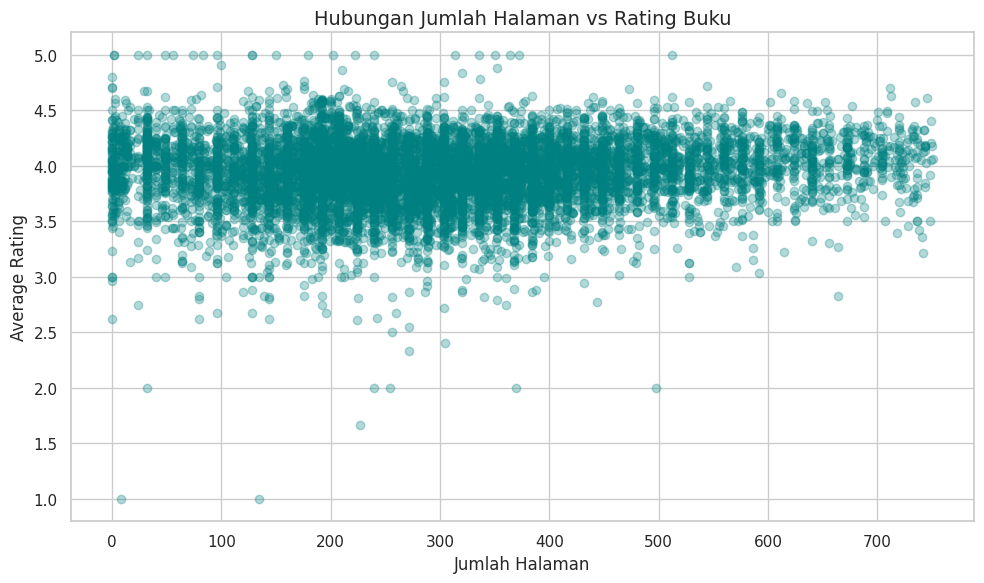

Korelasi antara jumlah halaman dan rating: 0.067


In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(df2['num_pages'], df2['average_rating'], alpha=0.3, color='teal')
plt.xlabel('Jumlah Halaman', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.title('Hubungan Jumlah Halaman vs Rating Buku', fontsize=14)
plt.tight_layout()
plt.show()

# Korelasi
corr = df2['num_pages'].corr(df2['average_rating'])
print(f"Korelasi antara jumlah halaman dan rating: {corr:.3f}")

Tidak ditemukan hubungan yang signifikan antara jumlah halaman buku dengan rating yang diberikan pembaca. Faktor lain seperti kualitas cerita, genre, atau penulis kemungkinan lebih berpengaruh terhadap rating dibanding panjang buku.

# 💡 Conclusion & Business Insight

### Ringkasan Temuan

1. **Distribusi Rating**
   Mayoritas buku memiliki rating antara 3.75–4.25, dengan rata-rata 3.93.
   Distribusi cenderung *left-skewed*, menunjukkan pembaca Goodreads
   umumnya memberi rating positif.

2. **Buku Terpopuler**
   *Twilight* menjadi buku dengan ratings terbanyak (4.6 juta), diikuti
   dominasi seri Harry Potter (3 dari 10 posisi teratas) — menunjukkan
   kuatnya loyalitas pembaca terhadap satu franchise/series.

3. **Bahasa Buku**
   94% buku dalam dataset berbahasa Inggris (eng, en-US, en-GB),
   menunjukkan adanya bias dataset terhadap pasar buku berbahasa Inggris.
   Hasil analisis tidak sepenuhnya mewakili tren membaca global.

4. **Penulis Produktif**
   P.G. Wodehouse merupakan penulis paling produktif (40 buku), diikuti
   beberapa nama besar seperti Stephen King dan Agatha Christie yang
   konsisten dengan reputasi mereka sebagai penulis prolifik.

5. **Jumlah Halaman vs Rating**
   Tidak ditemukan korelasi signifikan (r = 0.067) antara panjang buku
   dan rating. Ini mengindikasikan bahwa **kualitas konten**, bukan
   **panjang buku**, yang lebih menentukan penilaian pembaca.

### Business Insight
- Platform rekomendasi buku sebaiknya tidak menjadikan jumlah halaman
  sebagai faktor penentu rekomendasi
- Strategi pemasaran berbasis *franchise/series* (seperti Harry Potter)
  terbukti efektif membangun engagement jangka panjang dengan pembaca
- Diperlukan diversifikasi data buku non-Inggris untuk analisis yang
  lebih representatif secara global

### Keterbatasan
Dataset ini tidak memiliki kolom genre, sehingga analisis genre tidak
dapat dilakukan. Selain itu, dataset didominasi buku berbahasa Inggris
yang dapat membatasi generalisasi temuan.